## 1 概述
简单线性回归（Simple Linear Regression，缩写 SLR）算法是机器学习世界里的“Hello World”：它足够简单，能看清所有细节；它又足够深刻，能理解整个机器学习的核心。

## 2 数据集

鲍鱼数据集 (Abalone Dataset)，下载地址：https://archive.ics.uci.edu/dataset/1/abalone ；我们的目标是根据数据集训练一个模型，可以预测鲍鱼的年龄。

查看数据集的说明文件 abalone.names 可以发现样本 4177 条，特征 8 个，鲍鱼年龄的计算方法是 Rings+1.5 ，与 Rings （环数）相关系数 (Correl) 最大的特征是 Shell weight （壳重），由于 SLR 算法只需要一个特征，所以选择 Shell weight 。

打开数据集文件 abalone.data 可以看到如下内容：
```text
M,0.455,0.365,0.095,0.514,0.2245,0.101,0.15,15
M,0.35,0.265,0.09,0.2255,0.0995,0.0485,0.07,7
F,0.53,0.42,0.135,0.677,0.2565,0.1415,0.21,9
... 略 ...
```

只需要最后两列，分别是 Shell_weight 和 Rings，第一步就是把这两列提出来，然后加上列名保存为缓存文件 abalone_slr_processed.csv ：

In [3]:
import pandas as pd
import os

df = pd.read_csv('./datasets/abalone/abalone.data', header=None, 
                 names=['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings'])
X = df[['Shell_weight']]
y = df['Rings']
df_slr = df[['Shell_weight', 'Rings']]
out_dir = './outputs/slr'
os.makedirs(out_dir, exist_ok=True)
df_slr.to_csv(f'{out_dir}/abalone_processed.csv', index=False)

下面将数据集切分为训练集（占 80%）和测试集（占 20%），核心思想只是打乱样本顺序然后按比例切分：

In [5]:
import pandas as pd

df_slr = pd.read_csv('./outputs/slr/abalone_processed.csv')
# 打乱数据（frac=1 表示抽取 100% 的行，random_state=42 设置随机种子保证结过可复现）
df_shuffled = df_slr.sample(frac=1, random_state=42).reset_index(drop=True)
# 计算切分位置
split_idx = int(len(df_shuffled) * 0.8)
# 按位置切分
df_train = df_shuffled.iloc[:split_idx]
df_test = df_shuffled.iloc[split_idx:]
# 保存切分好的训练集和测试集
df_train.to_csv('./outputs/slr/abalone_train.csv', index=False)
df_test.to_csv('./outputs/slr/abalone_test.csv', index=False)

## 3 算法演示
为了直观理解算法到底要做什么，先画出训练集的散点图，如下：

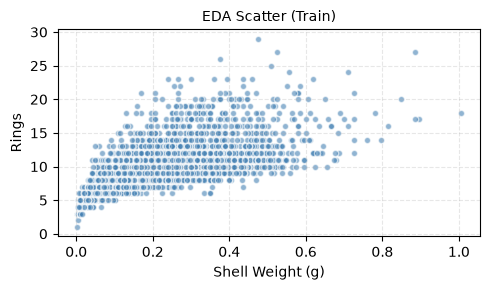

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df_train = pd.read_csv('./outputs/slr/abalone_train.csv')
plt.figure(figsize=(5, 3))  # 设置画布大小
# 绘制散点图；alpha=0.5 让重叠的点变透明，便于观察
plt.scatter(df_train['Shell_weight'], df_train['Rings'], 
            alpha=0.6, s=20, color='steelblue', edgecolors='white')
plt.xlabel('Shell Weight (g)', fontsize=10)
plt.ylabel('Rings', fontsize=10)
plt.title('EDA Scatter (Train)', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')   # 开启网格
plt.tight_layout()  # 自动调整布局
plt.savefig('./outputs/slr/eda_scatter_train.png', dpi=150, bbox_inches='tight')
plt.show()  # 展示图片

SLR 算法的目的是找到一条直线，尽量贴合图中点的分布，下面直接用 sklearn 训练出结果看看效果：

训练完成！拟合直线方程：Rings = 14.928140 * Shell_weight + 6.392470


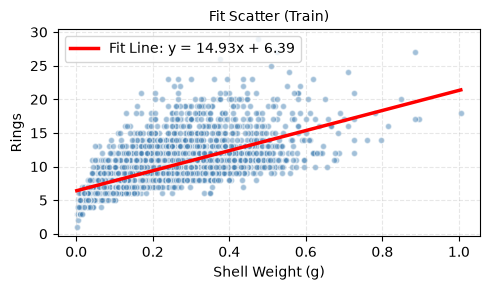

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

df_train = pd.read_csv('./outputs/slr/abalone_train.csv')
# 准备数据并训练模型
X_train = df_train[['Shell_weight']]
y_train = df_train['Rings']
model = LinearRegression()  # 线性回归
model.fit(X_train, y_train)
# 提取训练好的参数，即直线的参数
w = model.coef_[0]
b = model.intercept_
print(f"训练完成！拟合直线方程：Rings = {w:.6f} * Shell_weight + {b:.6f}")
# 绘制散点+直线的图
plt.figure(figsize=(5, 3))
plt.scatter(df_train['Shell_weight'], df_train['Rings'], alpha=0.5, s=20, 
            color='steelblue', edgecolors='white')
# 取训练集壳重的最小值和最大值作为直线两端
x_min = X_train.min().values[0]
x_max = X_train.max().values[0]
# 计算这两点对应的预测值
y_min = w * x_min + b
y_max = w * x_max + b
# 用 plot 画一条直线（两点确定一条直线）
plt.plot([x_min, x_max], [y_min, y_max], color='red',
    linewidth=2.5, label=f'Fit Line: y = {w:.2f}x + {b:.2f}')
plt.legend(loc='upper left', fontsize=10)    # label 显示位置
plt.xlabel('Shell Weight (g)', fontsize=10)
plt.ylabel('Rings', fontsize=10)
plt.title('Fit Scatter (Train)', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('./outputs/slr/fit_scatter_train.png', dpi=150)
plt.show()

拟合直线方程就是我们要的结果，下面要做的就是用测试集来验证，原理就是把测试集中样本的 Shell weight 代入方程得到预测结果，然后与该样本真实的结果进行对比：

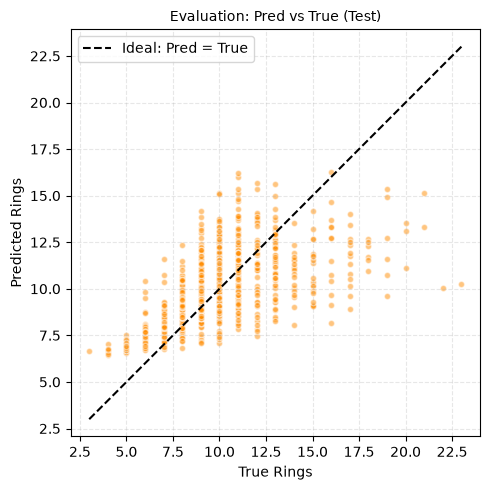

In [8]:
# 读取测试集
df_test = pd.read_csv('./outputs/slr/abalone_test.csv')
X_test = df_test[['Shell_weight']]
y_test = df_test['Rings']
# 用训练好的模型预测
y_pred = model.predict(X_test)
# 画图：预测值 vs 真实值（理想情况落在 y=x 对角线上）
plt.figure(figsize=(5, 5))
plt.scatter(y_test, y_pred, alpha=0.5, s=20,
    color='darkorange', edgecolors='white')
# 画 y=x 参考线（从最小环数到最大环数）
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', 
         linestyle='--', linewidth=1.5, label='Ideal: Pred = True')
plt.legend(loc='upper left', fontsize=10)
plt.xlabel('True Rings', fontsize=10)
plt.ylabel('Predicted Rings', fontsize=10)
plt.title('Evaluation: Pred vs True (Test)', fontsize=10)
plt.grid(True, alpha=0.3, linestyle='--')
plt.axis('equal')  # 让 x 轴和 y 轴比例一致，防止对角线变形
plt.tight_layout()
plt.savefig('./outputs/slr/eval_pred_vs_true.png', dpi=150)
plt.show()

> 这个图要解释下：  
> 1. 横坐标是真实环数，纵坐标是预测环数；  
> 1. 黑色对角线是 y=x 参考线，取的预测值和真实值中的最小值点（x=min,y=min）和最大值点（x=max,y=max）所画；  
> 1. 这个对角线代表“完美预测”；点越靠近线，表示预测的越准；点在线的上方表示预测值>真实值，预测偏小；点在线的下方表示预测值<真实值，预测偏大。  

## 4 算法机制
sklearn 用下面两句代码就完成了模型的训练，其内部到底做了什么呢？
```Python
model = LinearRegression()
model.fit(X_train, y_train)
```
既然我们的目标是一条直线，那先假设这个直线是：$y=wx+b$ ，目标就变成了找到合适的 $w,b$ 。怎么算合适呢，当然是预测值与真实值的误差尽量小，训练时 $y$ 当然表示真实值，训练完成后使用该方程得出的结果就是预测值 $\hat{y}$，所以单个样本的误差是：$y-\hat{y}=y-wx-b$，这个也叫残差；我们不能只看一个样本，全部样本的误差在 SLR 算法用的是残差平方和：$\sum_{i=1}^n(y_i-wx_i-b)^2$，平方可以放大误差且可导，其实把它除以 n 就是残差的方差，也叫 MSE （均方误差），是否除以 n 对公式求解没有影响，实际代码实现建议除以 n 使梯度可控、数值直观。

上面这段话已经包含了机器学习中的几个关键概念：
1. 斜率：$w$
1. 截距：$b$
1. 残差：$y-\hat{y}$
1. 假设函数：Hypothesis Function ，$y=wx+b$
1. 损失函数：Loss Function ，$L(w,b)=y-wx-b$
1. 代价函数：Cost Function ，$J(w,b)=\frac{1}{n}\sum_{i=1}^n(y_i-wx_i-b)^2$

至此，我们的目标变成了找到使总误差最小（或尽量小）的 $J(w,b)$，这是一个凸函数，其最小的点就是切线斜率为零的点，所以方法是求偏导并使偏导 =0 再解方程，结果是：
$$
b = \bar{y} - w \bar{x} \quad,\quad
w = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

> 推导过程看文末的`附：SLR 解析解公式推导过程`，这个推导不太重要，因为只在该算法有用。

用代码实现这个求 $w,b$ 的过程，将得到与 sklearn 一样的结果：

In [10]:
import pandas as pd
import numpy as np

df_train = pd.read_csv('./outputs/slr/abalone_train.csv')
X_train = df_train[['Shell_weight']]
y_train = df_train['Rings']
# 计算均值
x_bar = X_train['Shell_weight'].mean()
y_bar = y_train.mean()
# 计算 w 的分母和分子；用 NumPy 向量化计算，比循环快得多
S_xx = np.sum((X_train['Shell_weight'] - x_bar) ** 2)
S_xy = np.sum((X_train['Shell_weight'] - x_bar) * (y_train - y_bar))
# 求解 w,b
w = S_xy / S_xx
b = y_bar - w * x_bar
print(f"手动计算得到：斜率 w = {w:.6f}, 截距 b = {b:.6f}")
print(f"回归方程: Rings = {w:.6f} * Shell_weight + {b:.6f}")

手动计算得到：斜率 w = 14.928140, 截距 b = 6.392470
回归方程: Rings = 14.928140 * Shell_weight + 6.392470


手动计算得到了与 sklearn 一样的结果。

此时显然会有疑惑，机器学习不是一个迭代学习的过程吗？这里怎么好像没有过程，直接得出了结果。

没错，因为这是一个最简单的算法，只有一个特征的线性回归，其方程非常简单，直接就可以求解出来；当特征不止一个、数据量非常庞大时，求解方法会不一样，根本求不出或者说无法在有限时间内求出，此时就需要用先猜测、减少误差、再猜测的循环迭代过程来求一个误差尽量小的结果。

## 5 迭代求解
直接通过公式算出的结果叫`解析解`（也叫闭式解），通过迭代求得的近似值叫`数值解`，这两种都是机器学习，但现代 AI 的发展几乎完全押注在`迭代求数值解`这条路上。

迭代的过程简单来说就是先猜一个参数，比如 $w=0,b=0$，计算误差 $J(w,b)$，然后反复调整 $w,b$ 的值来减少误差，直到达到满意的近似值。

显然，每轮迭代如何调整 $w,b$ 来减少误差是关键，常用的方法是`梯度下降`。

### 5.1 梯度下降

什么是梯度：梯度是一个向量，是从函数上某点出发指向函数值增加最快的方向；求函数 $f(x,y,z)$ 在点 $(x_0,y_0,z_0)$ 的梯度是这样的: 
1. 求偏导: $f_x'(x_0,y_0,z_0)=a \quad,\quad  f_y'(x_0,y_0,z_0)=b \quad,\quad f_z'(x_0,y_0,z_0)=c$
2. $\overrightarrow{grad}f(x_0,y_0,z_0)=a\overrightarrow{i}+b\overrightarrow{j}+c\overrightarrow{k} \quad,\quad 其中 \overrightarrow{i},\overrightarrow{j},\overrightarrow{k}$ 是 $x,y,z$ 轴的单位向量

把函数比喻成一座山，梯度就是最陡的上坡方向；那梯度下降，就是最陡的下坡方向，即函数值下降最快的方向。

下面画一张图看看 $w$ 如何影响 $J(w)$ 的取值，以及直观看梯度下降（为简化将 $b$ 固定为解析解）：

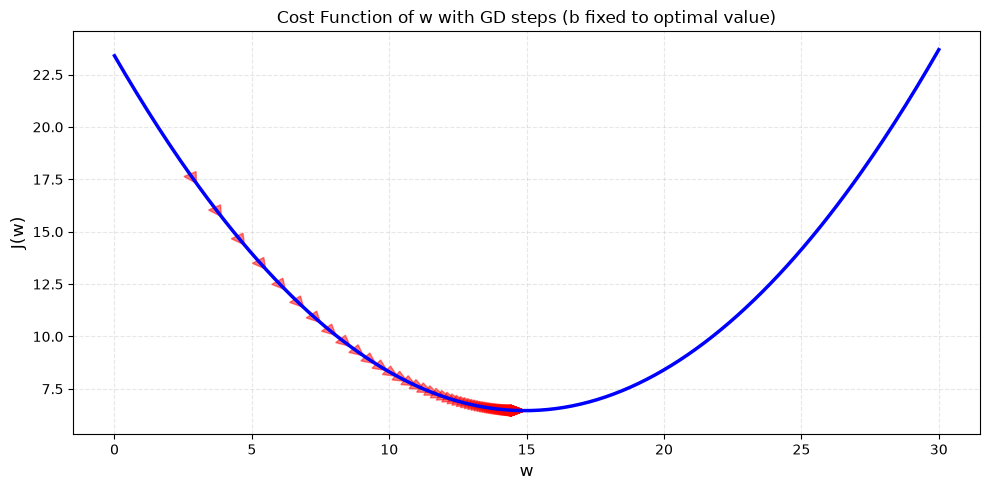

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 定义代价函数
def cost_func(w, X, y, b):
    y_pred = w * X.flatten() + b
    return np.mean((y - y_pred) ** 2)
# 载入训练集
df_train = pd.read_csv('./outputs/slr/abalone_train.csv')
X_train = df_train[['Shell_weight']].values
y_train = df_train['Rings'].values
# 横坐标 w 取值范围 0~30 , b 固定为最优解（解析解）
b_opt = 6.39
w_vals = np.linspace(0, 30, 300)
cost_vals = [cost_func(w, X_train, y_train, b_opt) for w in w_vals]
# 画 w 影响下的 J(w) 的曲线
plt.figure(figsize=(10, 5))
plt.plot(w_vals, cost_vals, color='blue', linewidth=2.5)
# 模拟梯度下降（只更新 w）
def gradient_descent_w(w_init, X, y, b, lr, epochs):
    w = w_init      # w 初始值
    n = len(X)      # 样本数
    # 保存起始点，即第一个脚印
    path_w = [w]    
    path_cost = [cost_func(w, X, y, b)]
    for _ in range(epochs):
        y_pred = w * X.flatten() + b    # 计算全部样本的预测值
        dw = (1/n) * np.sum((y_pred - y) * X.flatten()) # 计算平均梯度
        w = w - lr * dw # 更新参数，梯度下降，即迈出一步
        # 保存途径点，即途中的脚印
        path_w.append(w)
        path_cost.append(cost_func(w, X, y, b))
    return path_w, path_cost
# 梯度下降从 w=2 开始，学习率 lr=1 ，迭代 epochs=100 轮次
w_start = 2.0
path_w, path_cost = gradient_descent_w(w_start, X_train, y_train, b_opt, lr=1, epochs=100)
# 根据梯度下降，在 J(w) 曲线上画小箭头
for i in range(len(path_w)-1):
    x1, y1 = path_w[i], path_cost[i]
    x2, y2 = path_w[i+1], path_cost[i+1]
    dx = x2 - x1
    dy = y2 - y1
    plt.arrow(x1, y1, dx, dy, 
              head_width=0.5, head_length=0.5, 
              fc='red', ec='red', alpha=0.5, length_includes_head=True)
plt.xlabel('w', fontsize=12)
plt.ylabel('J(w)', fontsize=12)
plt.title('Cost Function of w with GD steps (b fixed to optimal value)', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('./outputs/slr/cost_function_of_w_with_GD.png', dpi=300)
plt.show()

如图所示，$J(w)$ 是一个凸函数，梯度下降从 $w=2$ 开始，沿着函数曲线往最低点走（固定 $b$ 后，二维平面上仅此一条路径）。可以观察到，随着 $w$ 接近最低点，步长越来越小，这种现象叫收敛速度递减——是算法正在稳定逼近最优解的健康信号。

看下面两句关键代码：
```python
dw = (1/n) * np.sum((y_pred - y) * X.flatten()) # 计算平均梯度
w = w - lr * dw                                 # 更新参数，梯度下降，即迈出一步
```
计算平均梯就是对代价函数 $J(w)$ 求偏导：$\frac{\partial J}{\partial w}=[\frac{1}{n}\sum(\hat{y}_i-y_i)^2]^{'}_w=\frac{1}{n}\sum(\hat{y}_i-y_i)x_i$
> 正常来说求导后还有一个 $2$，但乘一个正数不影响结果，为了简化通常定义 $\frac{1}{2}J(w)$ 把 $2$ 抵消

步长是 $lr \times dw$ 即：`学习率x平均梯度`，平均梯度由计算得来，所以控制步长是调整学习率来实现的，学习率太大会导致下降不平滑甚至在U型线的左右跳动，学习率太小会导致训练太慢，一般通过经验给一个初始值，比如 $0.1$ ，然后根据运行情况调整。

最后让 $w$ 减去这个步长：$w = w - lr * dw$ ，就实现了梯度下降。

### 6.2 停止条件与监测
上述梯度下降的代码，是直接设定了轮次 epochs=100 ，这还不是迭代求解，只是机械地走完规定的步数；真正的迭代求解应该包含一个智能的停止机制，在满足一定条件时自动停下来。

判断什么时候停止迭代几个标准（通常组合使用）：
1. 基于梯度的大小：当 $w$ 到达最底部时，切线是水平的，平均梯度 $dw$ 也应该等于 $0$ ，所以可以设置一个极小的容差 $tol$，当 $dw<tol$ 时自动停止。
1. 基于参数的变化量：就是步长 $lr \times dw$ ，当它足够小时，$w$ 的变化也可以忽略不计了，同样的道理设置 $tol$ 即可。
1. 基于代价函数的变化量：当代价函数 $J$ 的下降值小于某个容差 $tol$ 时。
1. 最大迭代次数：这是最后的安全绳，为了防止有 bug 或超参数设置不当导致无法收敛，一旦迭代次数达到 $max\_epochs$ 立刻强制退出，此时应该检查数据、代码或调整参数。
> 当参数扩展为多维（如 $w,b$）时：  
> - 梯度大小要用梯度范数计算，如：$||\Delta J||=\sqrt{(\frac{\partial J}{\partial w})^2+(\frac{\partial J}{\partial b})^2}$  
> - 参数变化量要用参数向量的欧氏距离，如：$||\Delta\theta||=\sqrt{(\Delta w)^2+(\Delta b)^2}$

> 参数与超参数：  
> - 参数：通过数据集自动学习出来的、求解出来的结果，如：斜率 $w$ 、截距 $b$ 。
> - 超参数：训练开始前，人为设定的控制学习过程的变量，如：起始值 $w\_init,b\_init$ 、学习率 $lr$、停止容差 $tol$ 、最大迭代次数 $max\_epochs$

除了停止条件，还需要监测训练过程中的运行状态，有三张图必须要看：
1. 损失变化图：横轴是迭代次数 $epochs$，纵轴是代价函数值 $J$；该曲线应该平滑地单调递减；若曲线上升或震荡，说明学习率太大；若曲线还陡就断了，说明迭代次数不够或学习率太小导致训练过慢。
1. 梯度变化图：横轴是迭代次数 $epochs$，纵轴是平均梯度的绝对值 $|dw|$；该曲线应该平滑地单调递减；若梯度突然变成无穷大 NaN ，说明样本中有极端数值或学习率过大导致溢出；若梯度剧烈跳动而不是平滑趋近于零，说明数据噪声大。
1. 参数变化图：直接监控参数 $w,b$ 的变化；应该是一条平滑的曲线；若出现来回交叉，说明学习率太大，越过了最低点；若变化太慢，说明学习率太小。

下面是完整的通过梯度下降迭代求解 $w,b$ 的代码，包含了四种停止条件和三种监测图：

✅ 停止于代价变化容差：第 47914 轮，代价变化 = 9.99e-13 < 1e-12

最终结果：w = 14.927804, b = 6.392551 (解析解：14.928140, 6.392470)
最终代价 J = 6.460722, 总迭代次数 = 47916


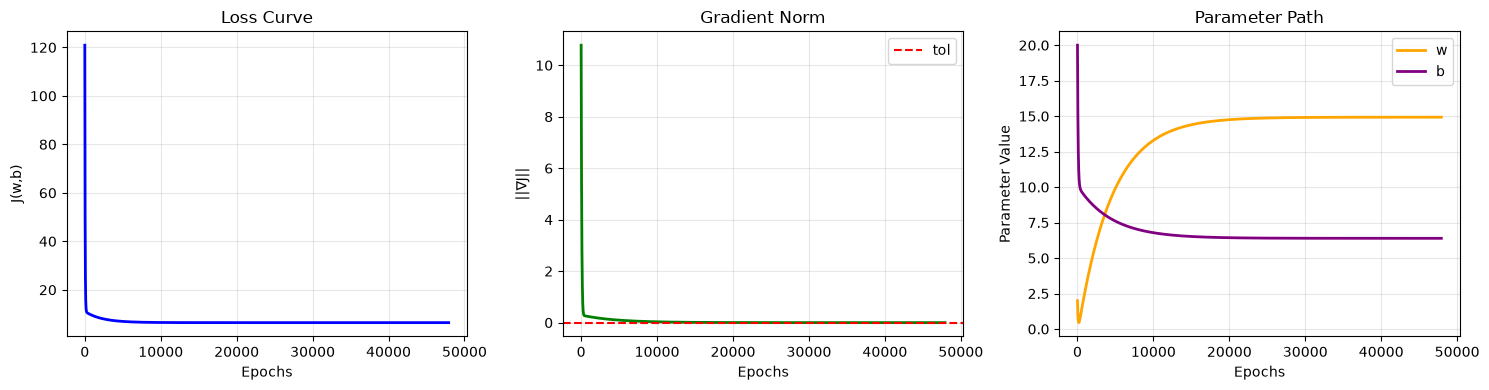

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 超参数
w_init = 2.0        # w 起始值
b_init = 20.0       # b 起始值
lr = 0.012          # 学习率
tol = 1e-12         # 容差
max_epochs = 100000 # 最大迭代次数
# 定义代价函数
def cost_func(w, b, X, y):
    y_pred = w * X + b
    return np.mean((y - y_pred) ** 2)
# 载入训练集
df_train = pd.read_csv('./outputs/slr/abalone_train.csv')
X_train = df_train[['Shell_weight']].values
y_train = df_train['Rings'].values
# 梯度下降函数（包含四种停止条件）；同时优化 w 和 b 的梯度下降，带多种停止条件。
# 返回：历史记录字典，包含 epochs, w_hist, b_hist, cost_hist, grad_norm_hist, param_change_hist
def gradient_descent_wb(X, y, w_init, b_init, lr, max_epochs, tol_grad, tol_param, tol_cost):
    w = w_init
    b = b_init
    n = len(X)
    # 记录历史
    w_hist = [w]
    b_hist = [b]
    cost_hist = [cost_func(w, b, X, y)]
    grad_norm_hist = []   # 记录每一轮的梯度范数
    param_change_hist = [] # 记录每一轮参数变化量

    for epoch in range(max_epochs):
        y_pred = w * X + b  # 预测值
        error = y_pred - y  # 残差
        # 计算 w,b 的平均梯度
        dw = (1/n) * np.sum(error * X)
        db = (1/n) * np.sum(error)
        # 计算本轮梯度范数
        grad_norm = np.sqrt(dw**2 + db**2)
        grad_norm_hist.append(grad_norm)
        # 停止条件1：梯度范数小于容差
        if grad_norm < tol_grad:
            print(f"✅ 停止于梯度容差：第 {epoch} 轮，梯度范数 = {grad_norm:.2e} < {tol_grad}")
            break
        # 更新参数
        w_new = w - lr * dw
        b_new = b - lr * db
        # 计算参数变化量
        param_change = np.sqrt((w_new - w)**2 + (b_new - b)**2)
        param_change_hist.append(param_change)
        # 计算新代价
        cost_new = cost_func(w_new, b_new, X, y)
        # 记录新参数
        w, b = w_new, b_new
        w_hist.append(w)
        b_hist.append(b)
        cost_hist.append(cost_new)
        # 停止条件2：参数变化量小于容差
        if param_change < tol_param:
            print(f"✅ 停止于参数变化容差：第 {epoch} 轮，参数变化 = {param_change:.2e} < {tol_param}")
            break
        # 停止条件3：代价变化量小于容差
        if abs(cost_hist[-1] - cost_hist[-2]) < tol_cost:
            print(f"✅ 停止于代价变化容差：第 {epoch} 轮，代价变化 = {abs(cost_hist[-1] - cost_hist[-2]):.2e} < {tol_cost}")
            break
    else:
        # 如果循环未被 break，说明达到了最大迭代次数
        print(f"⚠️ 达到最大迭代次数 {max_epochs}，算法未完全收敛，请考虑调整参数。")
    # 返回数据
    result = {
        'epochs': len(w_hist),
        'w_hist': w_hist,
        'b_hist': b_hist,
        'cost_hist': cost_hist,
        'grad_norm_hist': grad_norm_hist,   # 长度 = epochs-1 （因为第一次无梯度）
        'param_change_hist': param_change_hist  # 长度 = epochs-1
    }
    return result
# 运行梯度下降
history = gradient_descent_wb(X_train.flatten(), y_train, w_init=w_init, b_init=b_init,
    lr=lr, max_epochs=max_epochs, tol_grad=tol, tol_param=tol, tol_cost=tol)
# 绘制三个监测图
epochs = history['epochs']
w_hist = history['w_hist']
b_hist = history['b_hist']
cost_hist = history['cost_hist']
grad_norm_hist = history['grad_norm_hist']
param_change_hist = history['param_change_hist']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
# 图1：损失下降曲线
axes[0].plot(range(epochs), cost_hist, color='blue', linewidth=2)
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('J(w,b)')
axes[0].grid(True, alpha=0.3)
# 图2：梯度范数变化
axes[1].plot(range(len(grad_norm_hist)), grad_norm_hist, color='green', linewidth=2)
axes[1].axhline(y=1e-6, color='red', linestyle='--', label='tol')
axes[1].set_title('Gradient Norm')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('||∇J||')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
# 图3：参数轨迹（w 和 b 随更新步数的变化）
steps_param = range(epochs)
axes[2].plot(steps_param, w_hist, color='orange', label='w', linewidth=2)
axes[2].plot(steps_param, b_hist, color='purple', label='b', linewidth=2)
axes[2].set_title('Parameter Path')
axes[2].set_xlabel('Epochs')
axes[2].set_ylabel('Parameter Value')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./outputs/slr/gd_wb_monitor.png', dpi=150)
# 最终结果
print(f"\n最终结果：w = {w_hist[-1]:.6f}, b = {b_hist[-1]:.6f} (解析解：14.928140, 6.392470)")
print(f"最终代价 J = {cost_hist[-1]:.6f}, 总迭代次数 = {epochs}")
plt.show()

## 6 结语

不再把机器学习当作魔法，亲手推开了那扇门，看到了解析解公式背后的推导，看到了梯度下降的箭头一步步指向数值解，看到了损失曲线、梯度范数、参数轨迹共同提示模型正在收敛；后面的路还很长，但已经有了很好的起点。

## 附：SLR 解析解公式推导过程
是否除以 n 不影响公式推导，所以这里用不除以 n 的代价函数 $J(w,b)=\sum_{i=1}^n(y_i-wx_i-b)^2$

**对 $b$ 求偏导**：$\frac{\partial J}{\partial b}=-2\sum_{i=1}^n(y_i-wx_i-b)$ ，令其 =0 得：
$$
\sum_{i=1}^n(y_i-wx_i-b) = 0 \implies \sum_{i=1}^ny_i-w\sum_{i=1}^nx_i-\sum_{i=1}^nb=0
$$
已知：
$$
\frac{1}{n}\sum_{i=1}^ny_i=\bar{y} \quad,\quad \frac{1}{n}\sum_{i=1}^nx_i=\bar{x} \quad,\quad \frac{1}{n}\sum_{i=1}^nb=b
$$
所以将上面的式子两边除以 $n$ 得：$b=\bar{y}-w\bar{x}$


**对 $w$ 求偏导**：$\frac{\partial J}{\partial w}=-2\sum_{i=1}^nx_i(y_i-wx_i-b)$ ，令其 =0 得：
$$
\sum_{i=1}^nx_iy_i-w\sum_{i=1}^nx_i^2-b\sum_{i=1}^nx_i=0
$$
将 $b=\bar{y}-w\bar{x}$ 代入化简可得（下文 $\sum$ 太多，省略其上下标）：
$$
w=\frac{\sum x_iy_i-\bar{y}\sum x_i}{\sum x_i^2-\bar{x}\sum x_i}
$$
因为 $\bar{x},\bar{y}$ 不随 $i$ 变化，可以看作一个数，所以可知：
$$ 
n\bar{x}\bar{y}=\bar{y}\sum x_i=\bar{x}\sum y_i=\sum\bar{x}\bar{y}
$$
所以 **$w$ 的分子**：
$$
\sum x_iy_i-\bar{y}\sum x_i
=\sum x_iy_i-\bar{y}\sum x_i-\bar{x}\sum y_i+\sum\bar{x}\bar{y} \\
=\sum(x_iy_i-x_i\bar{y}-\bar{x}y_i+\bar{x}\bar{y}) \\
=\sum(x_i - \bar{x})(y_i - \bar{y})
$$
所以 **$w$ 的分母**：
$$
\sum x_i^2-\bar{x}\sum x_i
=\sum x_i^2-2\bar{x}\sum x_i+\bar{x}\sum x_i \\
=\sum x_i^2-2\bar{x}\sum x_i+n\bar{x}^2 \\
=\sum x_i^2-2\bar{x}\sum x_i+\sum\bar{x}^2 \\
=\sum(x_i^2-2\bar{x}x_i+\bar{x}^2) \\
=\sum(x_i - \bar{x})^2 \\ 
$$
故：$w=\frac{\sum(x_i - \bar{x})(y_i - \bar{y})}{\sum(x_i - \bar{x})^2}$

> 有意思的是这个式子正好是 **$x$ 与 $y$ 的协方差**除以 **$x$ 的方差**，即：$w=\frac{Cov(x,y)}{Var(x)}$

